# Análise Profunda: Master Dataset
Este notebook foca-se na análise detalhada do ficheiro `master_dataset.csv`, cruzando os dados financeiros, de urgências, internamentos, cirurgias e consultas para descobrir padrões e correlações.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
current_dir = os.getcwd()
pasta_raiz = os.path.dirname(current_dir) if os.path.basename(current_dir) == 'notebooks' else current_dir
file_path = os.path.join(pasta_raiz, 'data', 'processed', 'master_dataset.csv')

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Master Dataset loaded! Dimension: {df.shape[0]} rows and {df.shape[1]} columns.")
else:
    print("Error: Master Dataset not found at the expected path.")

Master Dataset loaded! Dimension: 8163 rows and 20 columns.


In [3]:
df.info()
display(df.head())
display(df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 8163 entries, 0 to 8162
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   regiao                                     8163 non-null   str    
 1   instituicao                                8163 non-null   str    
 2   ano                                        8163 non-null   int64  
 3   mes                                        8163 non-null   int64  
 4   ebitda                                     8163 non-null   float64
 5   gastos_operacionais                        8163 non-null   float64
 6   rendimentos_operacionais                   8163 non-null   float64
 7   resultado_liquido                          8163 non-null   float64
 8   resultados_operacionais                    8163 non-null   float64
 9   urgencias_geral                            8163 non-null   float64
 10  total_urgencias                    

,regiao,instituicao,ano,mes,ebitda,gastos_operacionais,rendimentos_operacionais,resultado_liquido,resultados_operacionais,urgencias_geral,total_urgencias,doentes_saidos,dias_de_internamento,no_intervencoes_cirurgicas_programadas,no_intervencoes_cirurgicas_convencionais,no_intervencoes_cirurgicas_de_ambulatorio,no_intervencoes_cirurgicas_urgentes,no_de_consultas_medicas_total,no_de_primeiras_consultas,no_de_consultas_subsequentes
0,Alentejo,Hospital Espírito Santo de Évora,2016,1,-434271.45,6658966.61,6011770.52,-671686.95,-647196.09,4600.0,6705.0,1091.0,7739.0,1016.0,365.0,651.0,135.0,15669.0,4855.0,10814.0
1,Alentejo,Hospital Espírito Santo de Évora,2016,2,-1055970.62,13705011.68,12224095.79,-1388851.48,-1480915.89,8829.0,12629.0,2122.0,15047.0,2082.0,734.0,1348.0,264.0,31400.0,9688.0,21712.0
2,Alentejo,Hospital Espírito Santo de Évora,2016,3,-1142753.35,20705767.00,18922454.36,-1651677.69,-1783312.64,13209.0,18624.0,3139.0,22364.0,3169.0,1145.0,2024.0,382.0,48131.0,14752.0,33379.0
3,Alentejo,Hospital Espírito Santo de Évora,2016,4,-1800956.00,27840405.52,25186147.68,-2302325.97,-2654257.84,17605.0,24808.0,4136.0,29617.0,4296.0,1538.0,2758.0,546.0,64082.0,19646.0,44436.0
4,Alentejo,Hospital Espírito Santo de Évora,2016,5,-2392387.54,34981080.80,31522123.71,-3087538.69,-3458957.09,22337.0,31556.0,5165.0,37014.0,5461.0,1963.0,3498.0,693.0,81420.0,24861.0,56559.0


,regiao,instituicao,ano,mes,ebitda,gastos_operacionais,rendimentos_operacionais,resultado_liquido,resultados_operacionais,urgencias_geral,total_urgencias,doentes_saidos,dias_de_internamento,no_intervencoes_cirurgicas_programadas,no_intervencoes_cirurgicas_convencionais,no_intervencoes_cirurgicas_de_ambulatorio,no_intervencoes_cirurgicas_urgentes,no_de_consultas_medicas_total,no_de_primeiras_consultas,no_de_consultas_subsequentes
count,8163,8163,8163.000000,8163.000000,8.163000e+03,8.163000e+03,8.163000e+03,8.163000e+03,8.163000e+03,8163.000000,8163.000000,8163.000000,8163.000000,8163.000000,8163.000000,8163.000000,8163.000000,8.163000e+03,8163.000000,8163.000000
unique,6,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Norte,Unidade Local de Saúde do Baixo Alentejo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2811,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2020.361264,6.497979,-7.212814e+06,6.416752e+07,5.571270e+07,-8.505060e+06,-8.546390e+06,34563.983952,47030.436849,6104.736616,52669.522479,5115.591082,1646.995467,3468.595614,776.379762,1.017571e+05,28850.146270,72906.963004
std,NaN,NaN,2.812390,3.449583,1.460514e+07,1.047761e+08,9.077846e+07,1.625743e+07,1.628299e+07,43394.298243,59847.535638,8127.785653,71208.470796,7373.351857,2512.204977,5001.549076,1164.160439,1.445765e+05,39476.941062,105684.083662
min,NaN,NaN,2016.000000,1.000000,-1.688819e+08,0.000000e+00,-6.411547e+06,-1.893682e+08,-1.886743e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,NaN,NaN,2018.000000,4.000000,-9.325541e+06,0.000000e+00,0.000000e+00,-1.104082e+07,-1.110258e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
50%,NaN,NaN,2020.000000,6.000000,-7.947452e+05,2.208227e+07,1.946116e+07,-1.364116e+06,-1.438592e+06,16943.000000,22692.000000,3194.000000,27197.000000,2471.000000,733.000000,1551.000000,320.000000,4.896500e+04,14753.000000,34181.000000
75%,NaN,NaN,2023.000000,9.000000,0.000000e+00,8.534226e+07,7.375347e+07,0.000000e+00,0.000000e+00,58424.000000,76999.500000,9168.500000,77925.000000,6994.000000,2157.000000,4856.000000,1119.000000,1.410515e+05,40664.000000,99998.500000


## Columns and Institutions Analysis
Verification of the number of unique institutions and their statistics.

In [4]:
if 'instituicao' in df.columns:
    num_institutions = df['instituicao'].nunique()
    print(f"There are {num_institutions} different institutions in the dataset.\n")
    print("All institutions and their record counts:")
    with pd.option_context('display.max_rows', None):
        display(df['instituicao'].value_counts().to_frame(name='Record Count'))
else:
    print("Column 'instituicao' not found in the dataset.")

There are 116 different institutions in the dataset.

All institutions and their record counts:


,Record Count
instituicao,
Unidade Local de Saúde do Baixo Alentejo,120
Unidade Local de Saúde do Litoral Alentejano,120
Instituto Português de Oncologia de Coimbra F. G.,120
Unidade Local de Saúde da Guarda,120
Unidade Local de Saúde de Coimbra,120
Hospital de Cascais,120
Instituto Português de Oncologia de Lisboa F. G.,120
Unidade Local de Saúde de Santa Maria,120
Unidade Local de Saúde de São José,120


## 1. Evolução Temporal Anual
Vamos agregar os dados por ano para ver a evolução a nível nacional da produtividade hospitalar.

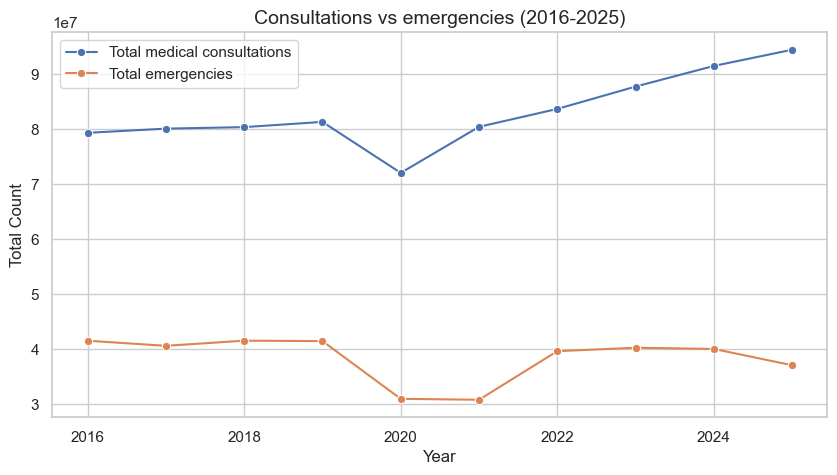

In [5]:
anual_evolution = df.groupby('ano').sum(numeric_only=True).reset_index()

plt.figure(figsize=(10, 5))
if 'no_de_consultas_medicas_total' in anual_evolution.columns:
    sns.lineplot(data=anual_evolution, x='ano', y='no_de_consultas_medicas_total', marker='o', label='Total medical consultations')
if 'total_urgencias' in anual_evolution.columns:
    sns.lineplot(data=anual_evolution, x='ano', y='total_urgencias', marker='o', label='Total emergencies')

plt.title('Consultations vs emergencies (2016-2025)', fontsize=14)
plt.ylabel('Total Count')
plt.xlabel('Year')
plt.legend()
plt.show()